In [42]:
%load_ext autoreload
%autoreload 2
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import scipy.stats as stats
from src.loading import *
from src.plotting import *
from src.binned_analysis import *
from src.saving import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# 1.75 minute if file has to be written, 8 seconds if file is already there
combined_feature_data = combined_feature_data = load_combined_features()

Loading combined features from /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/data/combined_features.pkl...


In [23]:
model_names = list(combined_feature_data.keys())
# Start from the active matplotlib color cycle
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
model_colors = {}
cycle_index = 0
for model_name in model_names:
    if model_name == "GPM":
        model_colors[model_name] = "black"
    else:
        model_colors[model_name] = color_cycle[cycle_index % len(color_cycle)]
        cycle_index += 1

# CDFs of MaxPr

In [13]:
def plot_cdf(series: pl.Series, ax: plt.Axes = None, label: str = None, **kwargs):
    values = series.drop_nulls().sort().to_numpy()
    cdf = np.arange(1, len(values) + 1) / len(values)
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
    ax.plot(values, cdf, label=label, **kwargs)  # unpack them here
    return fig, ax

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/CDF_MaxPr.pdf as PDF ...


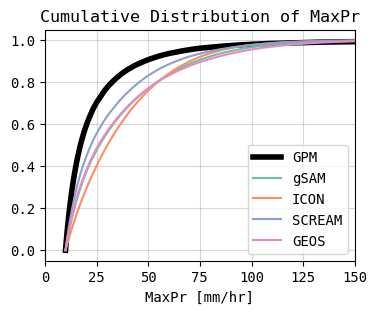

In [14]:
fig, ax = plt.subplots(figsize=(4, 3))

for model_name, df in combined_feature_data.items():
    kwargs = {
        "label": model_name,
        "color": model_colors[model_name],
    }

    if model_name == "GPM":
        kwargs["lw"] = 4

    plot_cdf(df["max_precip"], ax=ax, **kwargs)

ax.legend(loc='lower right')
ax.set_xlim(0, 150)
ax.set_xlabel('MaxPr [mm/hr]')
ax.set_title('Cumulative Distribution of MaxPr')
ax.grid(alpha=0.5)
save_figure(fig, 'CDF_MaxPr.pdf')

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/p99_MaxPr.pdf as PDF ...


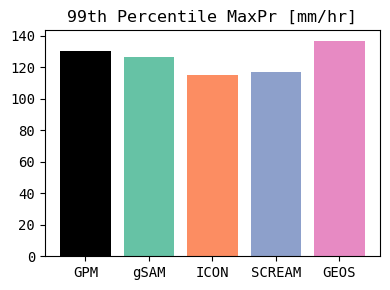

In [18]:
p99_values = {}

for model_name, df in combined_feature_data.items():
    p99_values[model_name] = df["max_precip"].quantile(0.99)

models = list(p99_values.keys())
values = list(p99_values.values())
color_list = [model_colors[m] for m in models]

fig, ax = plt.subplots(figsize=(4,3))
ax.bar(models, values, color=color_list)
# ax.set_ylabel("99th percentile of max_precip")
ax.set_title("99th Percentile MaxPr [mm/hr]")
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
save_figure(fig, 'p99_MaxPr.pdf')

# Size and Convective Concentration

GPM mean: x=7.21e+02, y=1.52e-01
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/GPM_all_pf_density.pdf as PDF ...
GPM extreme threshold (99th percentile): 130.10 mm/hr
GPM mean: x=2.51e+03, y=2.48e-01
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/GPM_extreme_PF_density.pdf as PDF ...
gSAM mean: x=1.60e+03, y=2.45e-01
gSAM mean: x=7.21e+02, y=1.52e-01
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/gSAM_all_pf_density.pdf as PDF ...
gSAM extreme threshold (99th percentile): 126.39 mm/hr
gSAM mean: x=1.20e+04, y=4.02e-01
gSAM mean: x=2.51e+03, y=2.48e-01
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/gSAM_extreme_PF_density.pdf as PDF ...
ICON mean: x=8.64e+02, y=3.05e-01
ICON mean: x=7.21e+02, y=1.52e-01
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ICON_all_pf_density.pdf as PDF ...
ICON extreme threshold (99th percentile): 115.03 mm/hr
ICON mean:

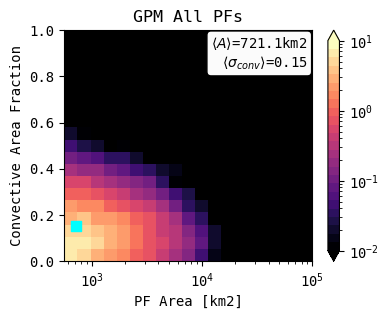

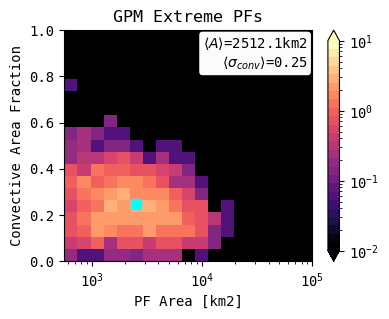

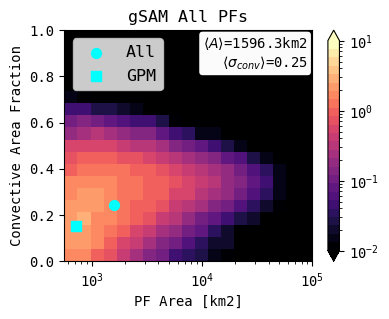

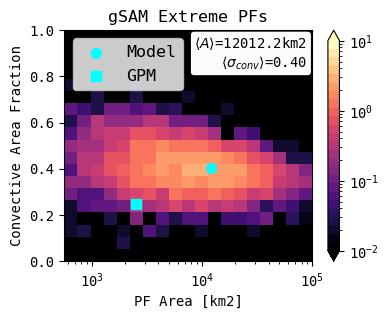

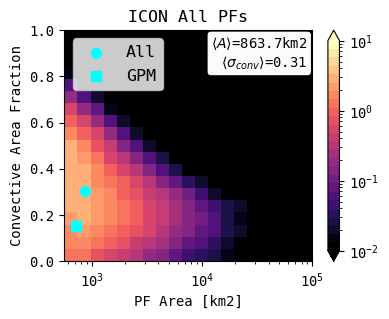

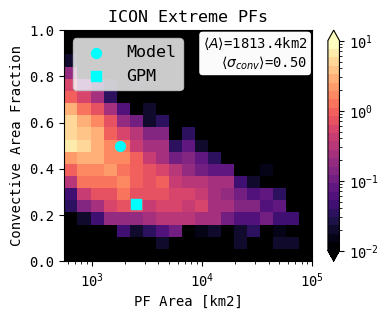

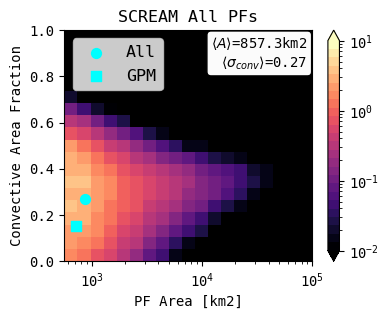

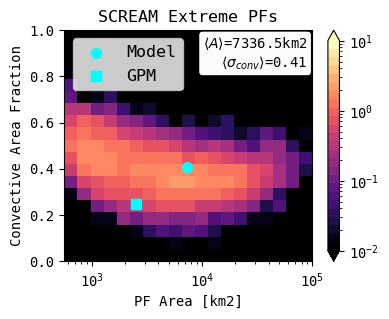

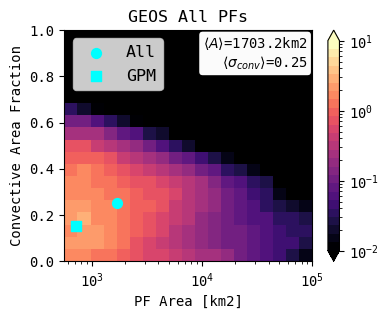

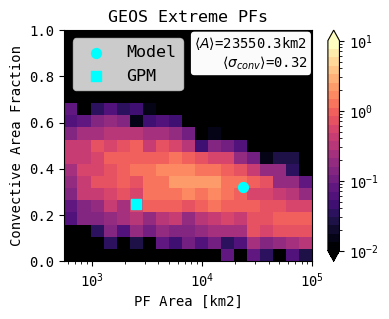

In [17]:
all_color = 'cyan'
extreme_color = 'cyan'
obs_color = 'cyan'

obs_marker = 's'
model_marker = 'o'
for model_name, df in combined_feature_data.items():
    x_bins = np.logspace(2.75, 5, 20)
    y_bins = np.linspace(0, 1, 20)
    cmap = discrete_cmap(plt.cm.magma, 25)
    norm = colors.LogNorm(vmin=1e-2, vmax=1e1)
    cmap.set_under('black')
    cmap.set_bad('black')

    x_all = df["number_pixels"] * gpm_area_factor()
    y_all = df["number_10mmhr_pixels"] / df["number_pixels"]
    # Plot the mean values
    def _plot_ref_mean(ax, x_data, y_data, color, marker, label=None, add_text=False, legend=True):
        x = np.nanmean(x_data)
        y = np.nanmean(y_data)
        s = 50
        ax.scatter(x, y, label=label, color=color, marker=marker, s=s,)
        print(f'{model_name} mean: x={x:.2e}, y={y:.2e}')
        if legend:
            ax.legend(loc='upper left', fontsize=12)
        if add_text:
            text = fr"$\langle A\rangle$={x:.1f}km2" + "\n" + rf"$\langle\sigma_{{conv}}\rangle$={y:.2f}"
            ax.text(
                0.98, 0.98, text,
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=10,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor="white",
                    alpha=0.99,
                    edgecolor="black",
                ),
            )

    # Plot the density
    fig, ax, data = plot_mean_stat(
        x_data=x_all,
        y_data=y_all,
        x_bins=x_bins,
        y_bins=y_bins,
        data_to_bin=None,
        statistic='count',
        density=True,
        cmap=cmap,
        norm=norm,
        return_data=True,
    )

    if model_name == 'GPM':
        _plot_ref_mean(ax, x_all, y_all, label=None, color=obs_color, marker=obs_marker, add_text=True, legend=False)
    else:
        _plot_ref_mean(ax, x_all, y_all, label='All', color=all_color, marker=model_marker, add_text=True)

        # add the gpm data
        gpm_x = combined_feature_data['GPM']["number_pixels"] * gpm_area_factor()
        gpm_y = combined_feature_data['GPM']["number_10mmhr_pixels"] / combined_feature_data['GPM']["number_pixels"]
        _plot_ref_mean(ax, gpm_x, gpm_y, label='GPM', color=obs_color, marker=obs_marker)

    ax.set_title(f'{model_name} All PFs')
    ax.set_xscale('log')
    ax.set_xlabel('PF Area [km2]')
    ax.set_ylabel('Convective Area Fraction')
    save_figure(fig, f'{model_name}_all_pf_density.pdf')

    # Plot the extreme values
    extreme_threshold = np.percentile(df['max_precip'].drop_nulls(), 99)
    print(f'{model_name} extreme threshold (99th percentile): {extreme_threshold:.2f} mm/hr')
    extreme_mask = df['max_precip'] >= extreme_threshold
    x_extreme = x_all.filter(extreme_mask)
    y_extreme = y_all.filter(extreme_mask)

    fig, ax, data = plot_mean_stat(
        x_data=x_extreme,
        y_data=y_extreme,
        x_bins=x_bins,
        y_bins=y_bins,
        data_to_bin=None,
        statistic='count',
        density=True,
        cmap=cmap,
        norm=norm,
        return_data=True,
    )

    if model_name == 'GPM':
        _plot_ref_mean(ax, x_extreme, y_extreme, label='', color=obs_color, marker=obs_marker, add_text=True, legend=False)
    else:
        _plot_ref_mean(ax, x_extreme, y_extreme, label='Model', color=extreme_color, marker=model_marker, add_text=True)

        # add the gpm data
        gpm_x = combined_feature_data['GPM']["number_pixels"] * gpm_area_factor()
        gpm_y = combined_feature_data['GPM']["number_10mmhr_pixels"] / combined_feature_data['GPM']["number_pixels"]
        gpm_extreme_thresh = np.percentile(combined_feature_data['GPM']['max_precip'].drop_nulls(), 99)
        gpm_extreme_mask = combined_feature_data['GPM']['max_precip'] >= gpm_extreme_thresh
        gpm_x_extreme = gpm_x.filter(gpm_extreme_mask)
        gpm_y_extreme = gpm_y.filter(gpm_extreme_mask)
        _plot_ref_mean(ax, gpm_x_extreme, gpm_y_extreme, label='GPM', color=obs_color, marker=obs_marker)

    ax.set_title(f'{model_name} Extreme PFs')
    ax.set_xscale('log')
    ax.set_xlabel('PF Area [km2]')
    ax.set_ylabel('Convective Area Fraction')
    save_figure(fig, f'{model_name}_extreme_PF_density.pdf')

# Sensitivity to HRL

/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:124: UserWarning: linewidths is ignored by contourf
  ax.contourf(


GPM $\Delta$MaxPr[%] significant-bin mean: 36.109
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/GPM_DeltaMaxPr.pdf as PDF ...


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:124: UserWarning: linewidths is ignored by contourf
  ax.contourf(


gSAM $\Delta$MaxPr[%] significant-bin mean: 12.412
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/gSAM_DeltaMaxPr.pdf as PDF ...


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:124: UserWarning: linewidths is ignored by contourf
  ax.contourf(


ICON $\Delta$MaxPr[%] significant-bin mean: 13.379
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/ICON_DeltaMaxPr.pdf as PDF ...


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:124: UserWarning: linewidths is ignored by contourf
  ax.contourf(


SCREAM $\Delta$MaxPr[%] significant-bin mean: 21.244
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/SCREAM_DeltaMaxPr.pdf as PDF ...


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:124: UserWarning: linewidths is ignored by contourf
  ax.contourf(


GEOS $\Delta$MaxPr[%] significant-bin mean: 13.731
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/GEOS_DeltaMaxPr.pdf as PDF ...


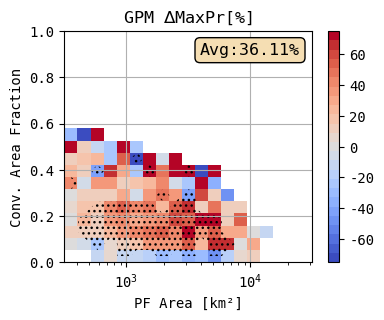

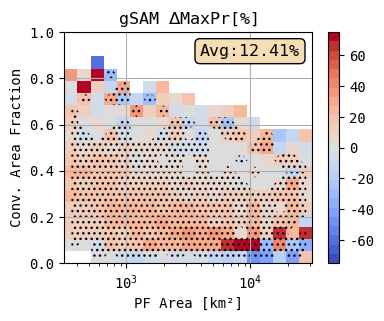

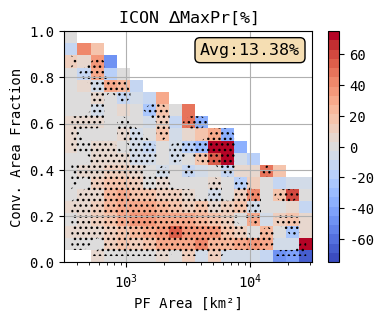

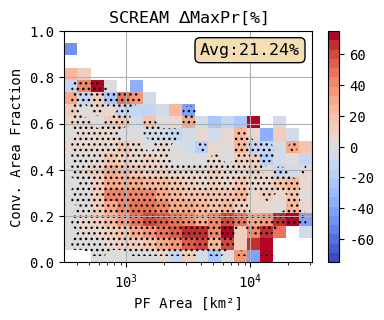

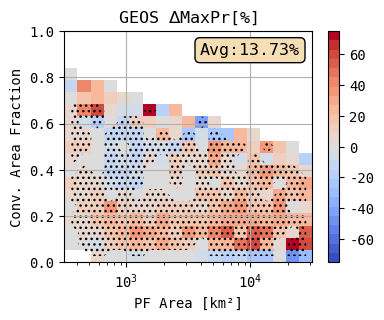

In [3]:
sig_mean_values = {}
for model_name, df in combined_feature_data.items():

    bqd = BinnedQuantileDelta(
        data_to_sort=df['largest_10mmhr_cluster'] / df['number_10mmhr_pixels'],
        data_to_diff=df['max_precip'],
        x_data=df['number_pixels'] * gpm_area_factor(),
        y_data=df['number_10mmhr_pixels'] / df['number_pixels'],
        x_bins=np.logspace(2.5, 4.5, 20),
        y_bins=np.linspace(0, 1, 20),
        low_quantile=(0, 0.1),
        high_quantile=(0.9, 1.0),
        percent_diff=True,
        samp_min=11,
        n_perm=200,
    )

    fig, ax, s, sig_mean = bqd.plot(
        xlabel='PF Area [km²]',
        ylabel='Conv. Area Fraction',
        title=f'{model_name} $\\Delta$MaxPr[%]',
        cmap=discrete_cmap(plt.cm.coolwarm, 25),
        norm=colors.TwoSlopeNorm(vmin=-75, vcenter=0, vmax=75),
    )
    sig_mean_values[model_name] = sig_mean

    save_figure(fig, f'{model_name}_DeltaMaxPr.pdf')

 

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Significant_Mean_DeltaMaxPr.pdf as PDF ...


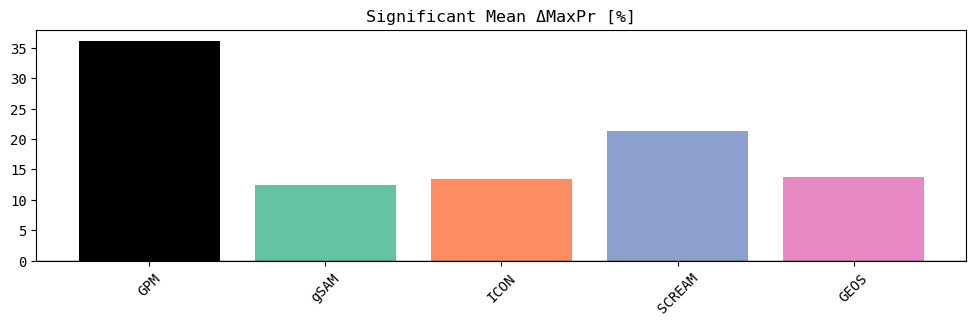

In [ ]:

models = list(sig_mean_values.keys())
values = [sig_mean_values[m] for m in models]
c = [model_colors[m] for m in models]

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(models, values, color=c)

ax.axhline(0, color="black", lw=1)
# ax.set_ylabel("Significant mean ΔMaxPr [%]")
ax.set_title("Significant Mean ΔMaxPr [%]")
ax.tick_params(axis="x", rotation=45)
save_figure(fig, 'Significant_Mean_DeltaMaxPr.pdf')

GPM $\Delta\rho_{conv}$ significant-bin mean: nan


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:13: UserWarning: linewidths is ignored by contourf
  Needed because scipy.binned_statistic_2d only accepts 1D values
/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:19: RuntimeWarning: Mean of empty slice
  for i, pair in enumerate(zip(col1, col2)):


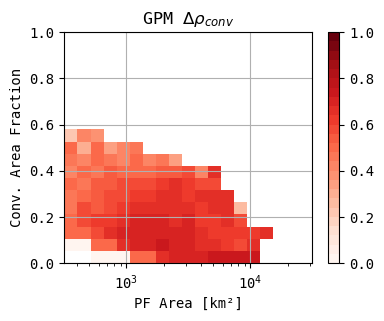

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Supplement_GPM_DeltaRhoConv.pdf as PDF ...
gSAM $\Delta\rho_{conv}$ significant-bin mean: nan


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:13: UserWarning: linewidths is ignored by contourf
  Needed because scipy.binned_statistic_2d only accepts 1D values
/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:19: RuntimeWarning: Mean of empty slice
  for i, pair in enumerate(zip(col1, col2)):


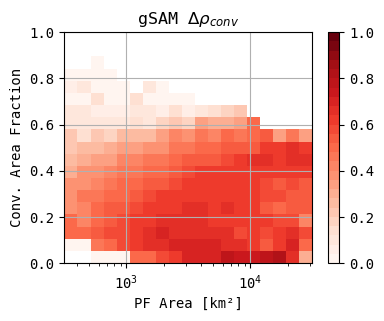

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Supplement_gSAM_DeltaRhoConv.pdf as PDF ...
ICON $\Delta\rho_{conv}$ significant-bin mean: nan


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:13: UserWarning: linewidths is ignored by contourf
  Needed because scipy.binned_statistic_2d only accepts 1D values
/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:19: RuntimeWarning: Mean of empty slice
  for i, pair in enumerate(zip(col1, col2)):


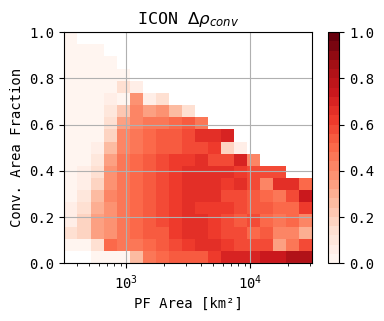

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Supplement_ICON_DeltaRhoConv.pdf as PDF ...
SCREAM $\Delta\rho_{conv}$ significant-bin mean: nan


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:13: UserWarning: linewidths is ignored by contourf
  Needed because scipy.binned_statistic_2d only accepts 1D values
/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:19: RuntimeWarning: Mean of empty slice
  for i, pair in enumerate(zip(col1, col2)):


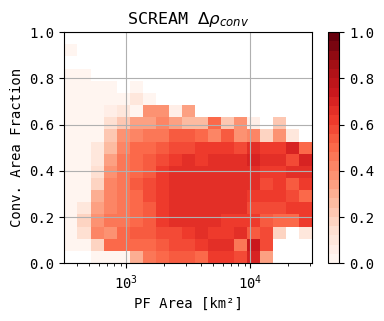

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Supplement_SCREAM_DeltaRhoConv.pdf as PDF ...
GEOS $\Delta\rho_{conv}$ significant-bin mean: nan


/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:13: UserWarning: linewidths is ignored by contourf
  Needed because scipy.binned_statistic_2d only accepts 1D values
/Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/src/binned_analysis.py:19: RuntimeWarning: Mean of empty slice
  for i, pair in enumerate(zip(col1, col2)):


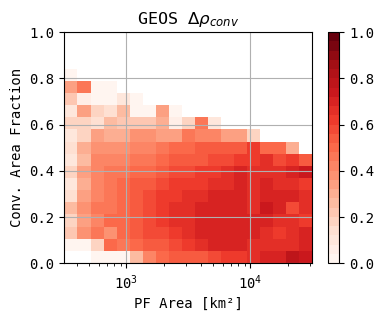

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/Supplement_GEOS_DeltaRhoConv.pdf as PDF ...


In [48]:
sig_mean_values = {}
for model_name, df in combined_feature_data.items():

    bqd = BinnedQuantileDelta(
        data_to_sort=df['largest_10mmhr_cluster'] / df['number_10mmhr_pixels'],
        data_to_diff=df['largest_10mmhr_cluster'] / df['number_10mmhr_pixels'],
        x_data=df['number_pixels'] * gpm_area_factor(),
        y_data=df['number_10mmhr_pixels'] / df['number_pixels'],
        x_bins=np.logspace(2.5, 4.5, 20),
        y_bins=np.linspace(0, 1, 20),
        low_quantile=(0, 0.1),
        high_quantile=(0.9, 1.0),
        percent_diff=False,
        samp_min=11,
        n_perm=0,
    )

    fig, ax, s, sig_mean = bqd.plot(
    xlabel='PF Area [km²]',
    ylabel='Conv. Area Fraction',
    title=fr'{model_name} $\Delta\rho_{{conv}}$',
    cmap=discrete_cmap(plt.cm.Reds, 25),
    norm=colors.Normalize(vmin=0, vmax=1),
    add_text=False
)
    plt.show()
    sig_mean_values[model_name] = np.nanmean(s)
    save_figure(fig, f'Supplement_{model_name}_DeltaRhoConv.pdf')


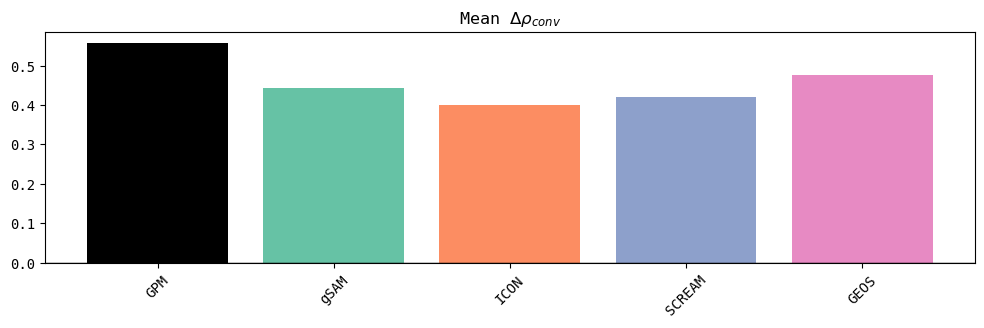

In [47]:
models = list(sig_mean_values.keys())
values = [sig_mean_values[m] for m in models]
c = [model_colors[m] for m in models]

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(models, values, color=c)

ax.axhline(0, color="black", lw=1)
# ax.set_ylabel("Significant mean ΔMaxPr [%]")
ax.set_title(rf"Mean $\Delta\rho_{{conv}}$")
ax.tick_params(axis="x", rotation=45)